In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from linearmodels import PanelOLS, RandomEffects, PooledOLS
from linearmodels.panel import compare
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

In [2]:
# # Set display options
# pd.set_option('display.max_rows', 10)
# pd.set_option('display.float_format', '{:.2f}'.format)

# # Create the toy dataset
# data = pd.DataFrame({
#     'company': ['A', 'A', 'A', 'A', 'A',
#                 'B', 'B', 'B', 'B', 'B',
#                 'C', 'C', 'C', 'C', 'C',
#                 'D', 'D', 'D', 'D', 'D',
#                 'E', 'E', 'E', 'E', 'E'],
#     'year': [2019, 2020, 2021, 2022, 2023] * 5,
#     'profit_margin': [10.2, 10.5, 11.0, 10.8, 11.5,
#                       15.1, 15.5, 16.0, 16.2, 17.0,
#                       5.5, 5.8, 6.1, 6.0, 6.8,
#                       20.1, 20.5, 21.0, 21.2, 22.0,
#                       8.1, 8.5, 9.0, 8.8, 9.5],
#     'rd_spending': [4.1, 4.3, 4.5, 4.4, 4.8,
#                     2.1, 2.2, 2.5, 2.6, 3.0,
#                     8.1, 8.3, 8.5, 8.4, 9.0,
#                     1.1, 1.2, 1.5, 1.6, 2.0,
#                     6.1, 6.3, 6.5, 6.4, 6.8]
# })

# # Display the first few rows
# print("Dataset Preview:")
# print(data.head(10))
# print("\nDataset Info:")
# print(f"Number of observations: {len(data)}")
# print(f"Number of companies: {data['company'].nunique()}")
# print(f"Years: {data['year'].min()} to {data['year'].max()}")

In [3]:
# # IMPORTANT: Set the multi-index for panel data
# # The index must be (entity, time) for linearmodels
# data = data.set_index(['company', 'year'])
# data = data.sort_index()

# print("\nData with Panel Index:")
# print(data.head(10))
# print("\nIndex structure:")
# print(data.index)

In [4]:
# # Create visualization to understand the data
# fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# # 1. Time trends by company
# for company in data.index.get_level_values('company').unique():
#     company_data = data.xs(company, level='company')
#     axes[0, 0].plot(company_data.index, company_data['profit_margin'], 
#                     marker='o', label=f'Company {company}')
# axes[0, 0].set_title('Profit Margin Trends by Company')
# axes[0, 0].set_xlabel('Year')
# axes[0, 0].set_ylabel('Profit Margin (%)')
# axes[0, 0].legend()
# axes[0, 0].grid(True, alpha=0.3)

# # 2. R&D spending trends
# for company in data.index.get_level_values('company').unique():
#     company_data = data.xs(company, level='company')
#     axes[0, 1].plot(company_data.index, company_data['rd_spending'], 
#                     marker='s', label=f'Company {company}')
# axes[0, 1].set_title('R&D Spending Trends by Company')
# axes[0, 1].set_xlabel('Year')
# axes[0, 1].set_ylabel('R&D Spending (% of Revenue)')
# axes[0, 1].legend()
# axes[0, 1].grid(True, alpha=0.3)

# # 3. Scatter plot: R&D vs Profit Margin
# axes[1, 0].scatter(data['rd_spending'], data['profit_margin'], alpha=0.5)
# axes[1, 0].set_xlabel('R&D Spending (% of Revenue)')
# axes[1, 0].set_ylabel('Profit Margin (%)')
# axes[1, 0].set_title('R&D Spending vs Profit Margin')
# axes[1, 0].grid(True, alpha=0.3)

# # Add a regression line
# z = np.polyfit(data['rd_spending'], data['profit_margin'], 1)
# p = np.poly1d(z)
# axes[1, 0].plot(data['rd_spending'].sort_values(), 
#                 p(data['rd_spending'].sort_values()), 
#                 "r--", alpha=0.8, label='Trend line')
# axes[1, 0].legend()

# # 4. Boxplot by company
# data.groupby('company')['profit_margin'].mean().sort_values().plot(
#     kind='bar', ax=axes[1, 1], color='skyblue', edgecolor='black')
# axes[1, 1].set_title('Average Profit Margin by Company')
# axes[1, 1].set_xlabel('Company')
# axes[1, 1].set_ylabel('Average Profit Margin (%)')
# axes[1, 1].grid(True, alpha=0.3, axis='y')

# plt.tight_layout()
# plt.show()

# # Summary statistics
# print("\nSummary Statistics:")
# print(data.describe())

# # Between and within variation
# print("\nVariation Decomposition:")
# print("Between-company variation (standard deviation of company means):")
# company_means = data.groupby('company').mean()
# print(company_means.std())

# print("\nWithin-company variation (average of within-company std devs):")
# within_std = data.groupby('company').std().mean()
# print(within_std)

In [15]:
data = pd.read_excel(r'data\WDI_GFDI_finance.xlsx')

In [16]:
data = data.pivot_table(index=['Country Name', 'Year'],
                       columns=['Indicator Name'],
                                 values=['Value'],
                                 aggfunc='sum')#.to_excel(r'wdi_piovt.xlsx')

In [17]:
data.columns = data.columns.droplevel(0) 

In [18]:
data['Bank deposits to GDP (constant 2015 US$)'] = data['Bank deposits to GDP (%)'] * data['GDP (constant 2015 US$)']/100
data['Domestic credit to private sector (constant 2015 US$)'] = data['Domestic credit to private sector (% of GDP)'] * data['GDP (constant 2015 US$)']/100
data['Market capitalization of listed domestic companies (constant 2015 US$)'] = data['Market capitalization of listed domestic companies (% of GDP)'] * data['GDP (constant 2015 US$)']/100
data['Stocks traded, total value (constant 2015 US$)'] = data['Stocks traded, total value (% of GDP)'] * data['GDP (constant 2015 US$)']/100

In [19]:
data_test_df = data.copy()

In [20]:
data_test_df.rename(columns={'Bank deposits to GDP (constant 2015 US$)' : 'Bank deposits'
                             , 'Domestic credit to private sector (constant 2015 US$)' : 'Domestic credit'
                             , 'Stocks traded, total value (constant 2015 US$)' : 'Stocks traded'
                             , 'Market capitalization of listed domestic companies (constant 2015 US$)' : 'Market capitalization'
                             , 'GDP (constant 2015 US$)' : 'GDP'
                            }, inplace=True)

# data_test_df = data_test_df[['GDP'
#                              , 'Bank deposits'
#                              , 'Domestic credit'
#                              , 'Market capitalization'
#                              , 'Stocks traded'
#                             ]]

In [21]:
# # Create visualization to understand the data
# fig, axes = plt.subplots(2, 2, figsize=(19, 14))

# # 1. Time trends by company
# for country in data_test_df.index.get_level_values(0).unique():
#     data_test_df_temp = data_test_df.loc[country]
#     axes[0, 0].scatter(data_test_df_temp['Bank deposits to GDP (%)']
#                        , data_test_df_temp['GDP']
#                        , alpha=0.5
#                        # , s = 10
#                        , label=country
#                        # , marker ='.'
#                        , color = sns.color_palette('gray', len(data_test_df.index.get_level_values(0).unique())+5)[list(data_test_df.index.get_level_values(0).unique()).index(country)])
#     axes[0, 0].set_xlabel('Bank deposits')
#     axes[0, 0].set_ylabel('GDP')
#     axes[0, 0].set_title('Bank deposits vs GDP')
#     axes[0, 0].grid(True, alpha=0.3)
#     axes[0, 0].legend()


# # 2. R&D spending trends
# for country in data_test_df.index.get_level_values(0).unique():
#     data_test_df_temp = data_test_df.loc[country]
#     axes[0, 1].scatter(data_test_df_temp['Domestic credit to private sector (% of GDP)'], data_test_df_temp['GDP'], alpha=0.5, label=country, color = sns.color_palette('gray', len(data_test_df.index.get_level_values(0).unique())+5)[list(data_test_df.index.get_level_values(0).unique()).index(country)])
#     axes[0, 1].set_xlabel('Domestic credit')
#     axes[0, 1].set_ylabel('GDP')
#     axes[0, 1].set_title('Domestic credit vs GDP')
#     axes[0, 1].grid(True, alpha=0.3)
#     axes[0, 1].legend()


# # 3. Scatter plot: R&D vs Profit Margin
# for country in data_test_df.index.get_level_values(0).unique():
#     data_test_df_temp = data_test_df.loc[country]
#     axes[1, 0].scatter(data_test_df_temp['Market capitalization of listed domestic companies (% of GDP)'], data_test_df_temp['GDP'], alpha=0.5, label=country, color = sns.color_palette('gray', len(data_test_df.index.get_level_values(0).unique())+5)[list(data_test_df.index.get_level_values(0).unique()).index(country)])
#     axes[1, 0].set_xlabel('Market capitalization')
#     axes[1, 0].set_ylabel('GDP')
#     axes[1, 0].set_title('Market capitalization vs GDP')
#     axes[1, 0].grid(True, alpha=0.3)
#     axes[1, 0].legend()

# # 4. Boxplot by company
# for country in data_test_df.index.get_level_values(0).unique():
#     data_test_df_temp = data_test_df.loc[country]
#     axes[1, 1].scatter(data_test_df_temp['Stocks traded, total value (% of GDP)'], data_test_df_temp['GDP'], alpha=0.5, label=country, color = sns.color_palette('gray', len(data_test_df.index.get_level_values(0).unique())+5)[list(data_test_df.index.get_level_values(0).unique()).index(country)])
#     axes[1, 1].set_xlabel('Stocks traded')
#     axes[1, 1].set_ylabel('GDP')
#     axes[1, 1].set_title('Stocks traded vs GDP')
#     axes[1, 1].grid(True, alpha=0.3)
#     axes[1, 1].legend()

# plt.show()

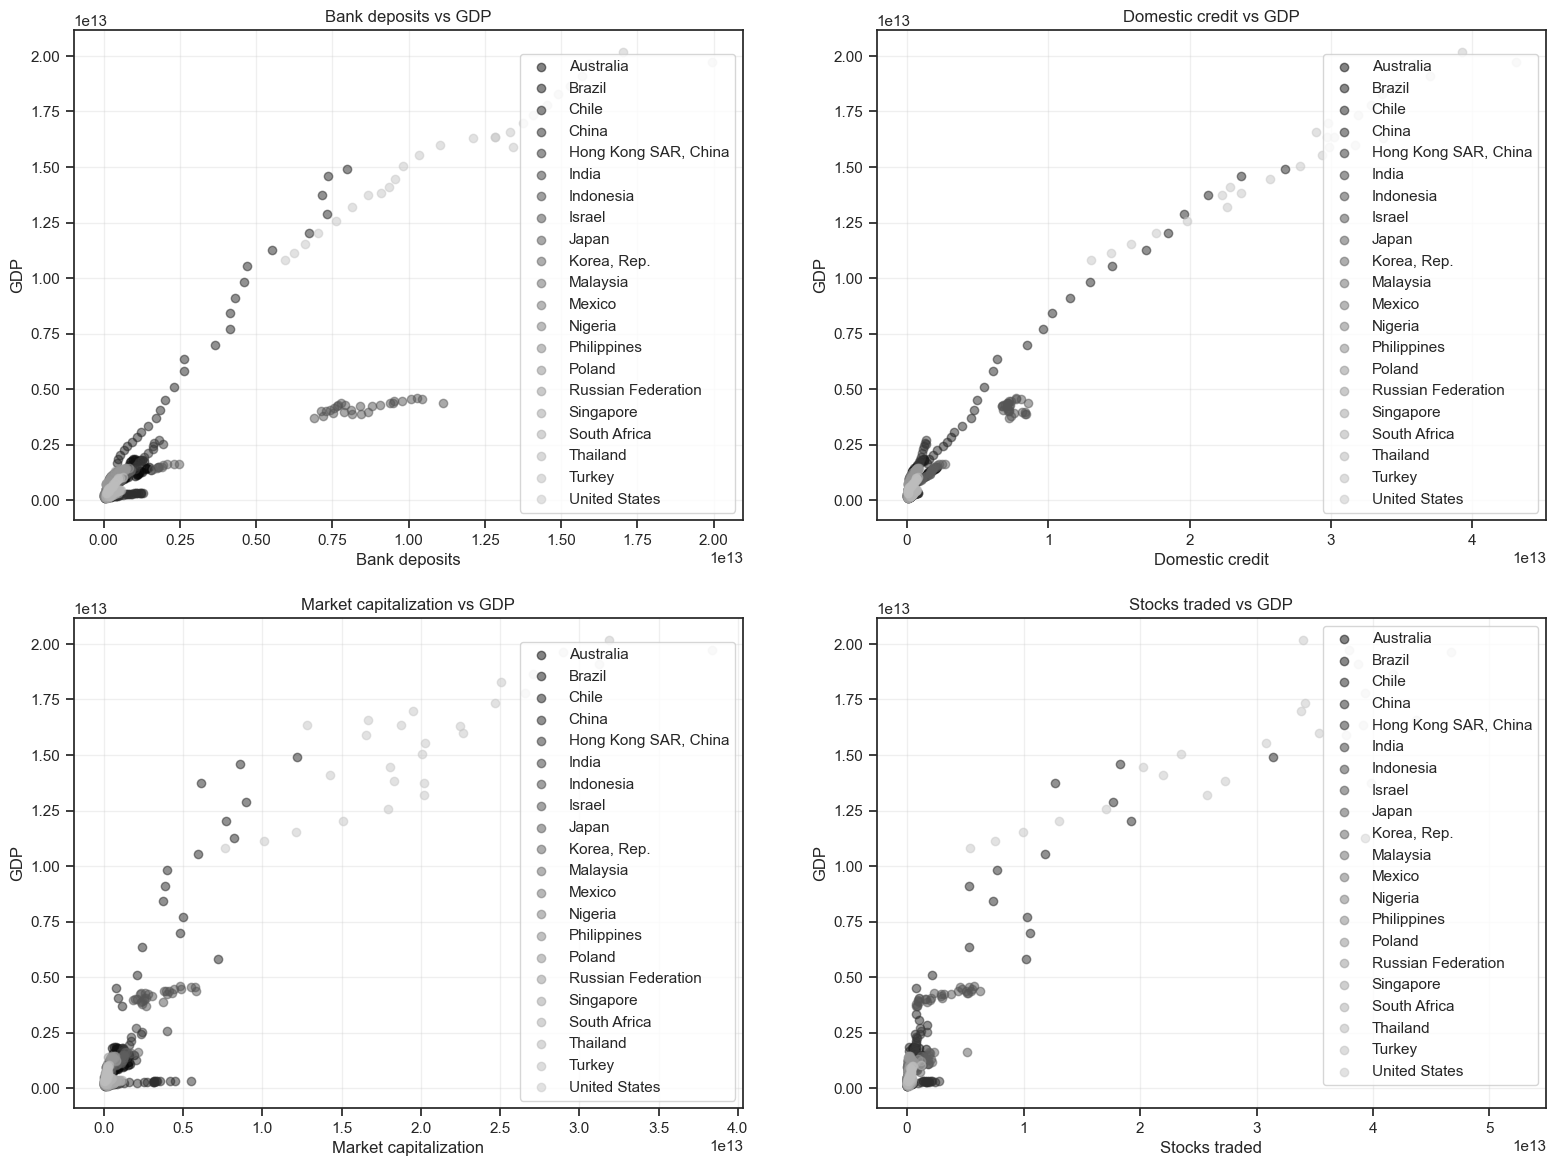

In [22]:
sns.set_theme(style="ticks", font_scale=1)
# Create visualization to understand the data
fig, axes = plt.subplots(2, 2, figsize=(19, 14))

# 1. Time trends by company
for country in data_test_df.index.get_level_values(0).unique():
    data_test_df_temp = data_test_df.loc[country]
    axes[0, 0].scatter(data_test_df_temp['Bank deposits']
                       , data_test_df_temp['GDP']
                       , alpha=0.5
                       # , s = 10
                       , label=country
                       # , marker ='.'
                       , color = sns.color_palette('gray', len(data_test_df.index.get_level_values(0).unique())+5)[list(data_test_df.index.get_level_values(0).unique()).index(country)])
    axes[0, 0].set_xlabel('Bank deposits')
    axes[0, 0].set_ylabel('GDP')
    axes[0, 0].set_title('Bank deposits vs GDP')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()


# 2. R&D spending trends
for country in data_test_df.index.get_level_values(0).unique():
    data_test_df_temp = data_test_df.loc[country]
    axes[0, 1].scatter(data_test_df_temp['Domestic credit'], data_test_df_temp['GDP'], alpha=0.5, label=country, color = sns.color_palette('gray', len(data_test_df.index.get_level_values(0).unique())+5)[list(data_test_df.index.get_level_values(0).unique()).index(country)])
    axes[0, 1].set_xlabel('Domestic credit')
    axes[0, 1].set_ylabel('GDP')
    axes[0, 1].set_title('Domestic credit vs GDP')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()


# 3. Scatter plot: R&D vs Profit Margin
for country in data_test_df.index.get_level_values(0).unique():
    data_test_df_temp = data_test_df.loc[country]
    axes[1, 0].scatter(data_test_df_temp['Market capitalization'], data_test_df_temp['GDP'], alpha=0.5, label=country, color = sns.color_palette('gray', len(data_test_df.index.get_level_values(0).unique())+5)[list(data_test_df.index.get_level_values(0).unique()).index(country)])
    axes[1, 0].set_xlabel('Market capitalization')
    axes[1, 0].set_ylabel('GDP')
    axes[1, 0].set_title('Market capitalization vs GDP')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()

# 4. Boxplot by company
for country in data_test_df.index.get_level_values(0).unique():
    data_test_df_temp = data_test_df.loc[country]
    axes[1, 1].scatter(data_test_df_temp['Stocks traded'], data_test_df_temp['GDP'], alpha=0.5, label=country, color = sns.color_palette('gray', len(data_test_df.index.get_level_values(0).unique())+5)[list(data_test_df.index.get_level_values(0).unique()).index(country)])
    axes[1, 1].set_xlabel('Stocks traded')
    axes[1, 1].set_ylabel('GDP')
    axes[1, 1].set_title('Stocks traded vs GDP')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()

plt.show()

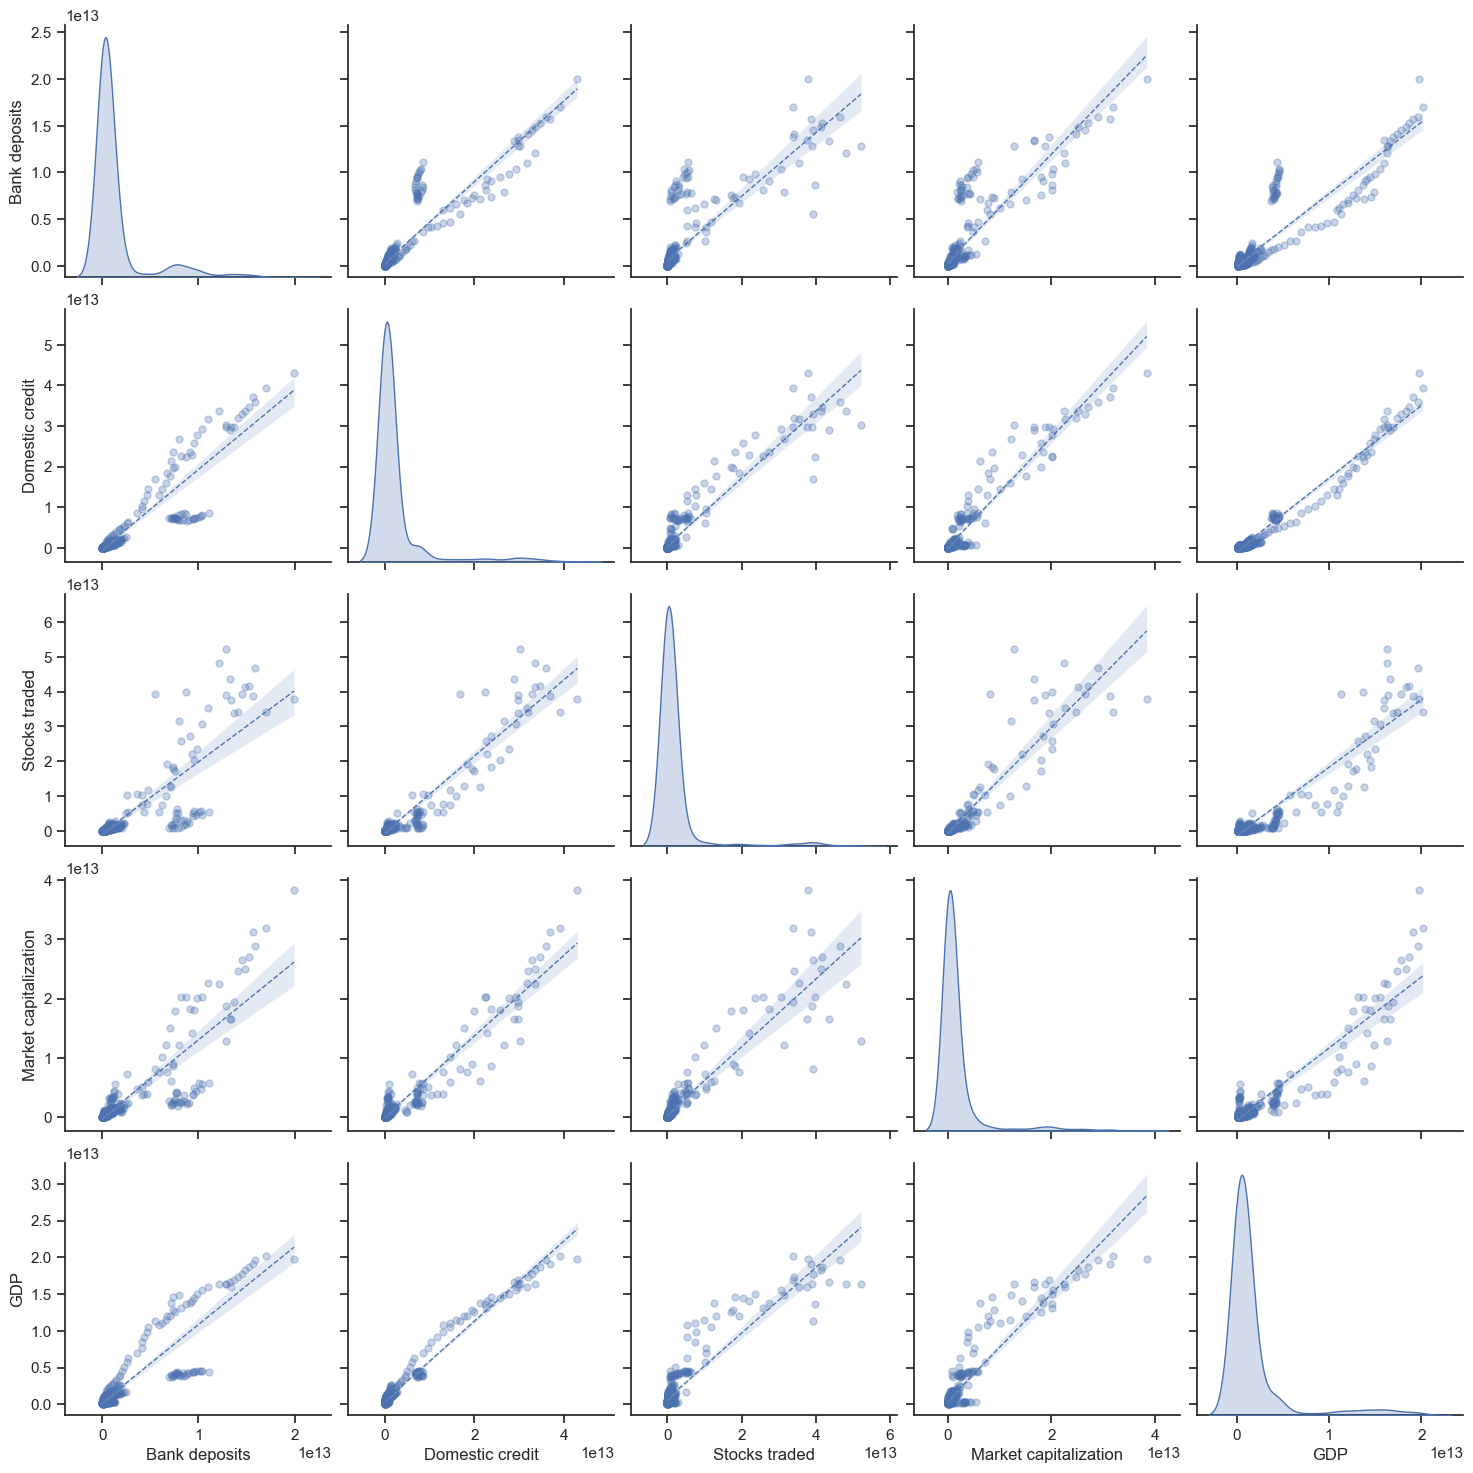

In [24]:
# sns.set_theme(style="ticks", font_scale=1)

sns.pairplot(
    data_test_df[['Bank deposits'
                  , 'Domestic credit'
                  , 'Stocks traded'
                  , 'Market capitalization'
                  , 'GDP'
                  # , 'Country Name'
                 ]]
    
    , kind='reg'
    , diag_kind = 'kde'
    , height=3
    , plot_kws={'line_kws': {'linestyle': '--'
                             , 'linewidth': 1
                            }
                , 'scatter_kws': {'s': 25
                                  , 'alpha': 0.3}
               }
    , dropna=True
)


In [25]:
data_test_df = pd.DataFrame()

for country in data.index.get_level_values(0).unique():
    country_df = data.loc[country].diff(1)
    country_df['Country Name'] = country
    country_df.reset_index(inplace= True)
    data_test_df = pd.concat([data_test_df, country_df])    

data_test_df = data_test_df.set_index(['Country Name', 'Year'])

data_test_df.rename(columns={'Bank deposits to GDP (constant 2015 US$)' : 'Bank deposits'
                             , 'Domestic credit to private sector (constant 2015 US$)' : 'Domestic credit'
                             , 'Stocks traded, total value (constant 2015 US$)' : 'Stocks traded'
                             , 'Market capitalization of listed domestic companies (constant 2015 US$)' : 'Market capitalization'
                             , 'GDP (constant 2015 US$)' : 'GDP'
                            }, inplace=True)

data_test_df = data_test_df[['GDP'
                             , 'Bank deposits'
                             , 'Domestic credit'
                             , 'Market capitalization'
                             , 'Stocks traded'
                            ]].dropna()

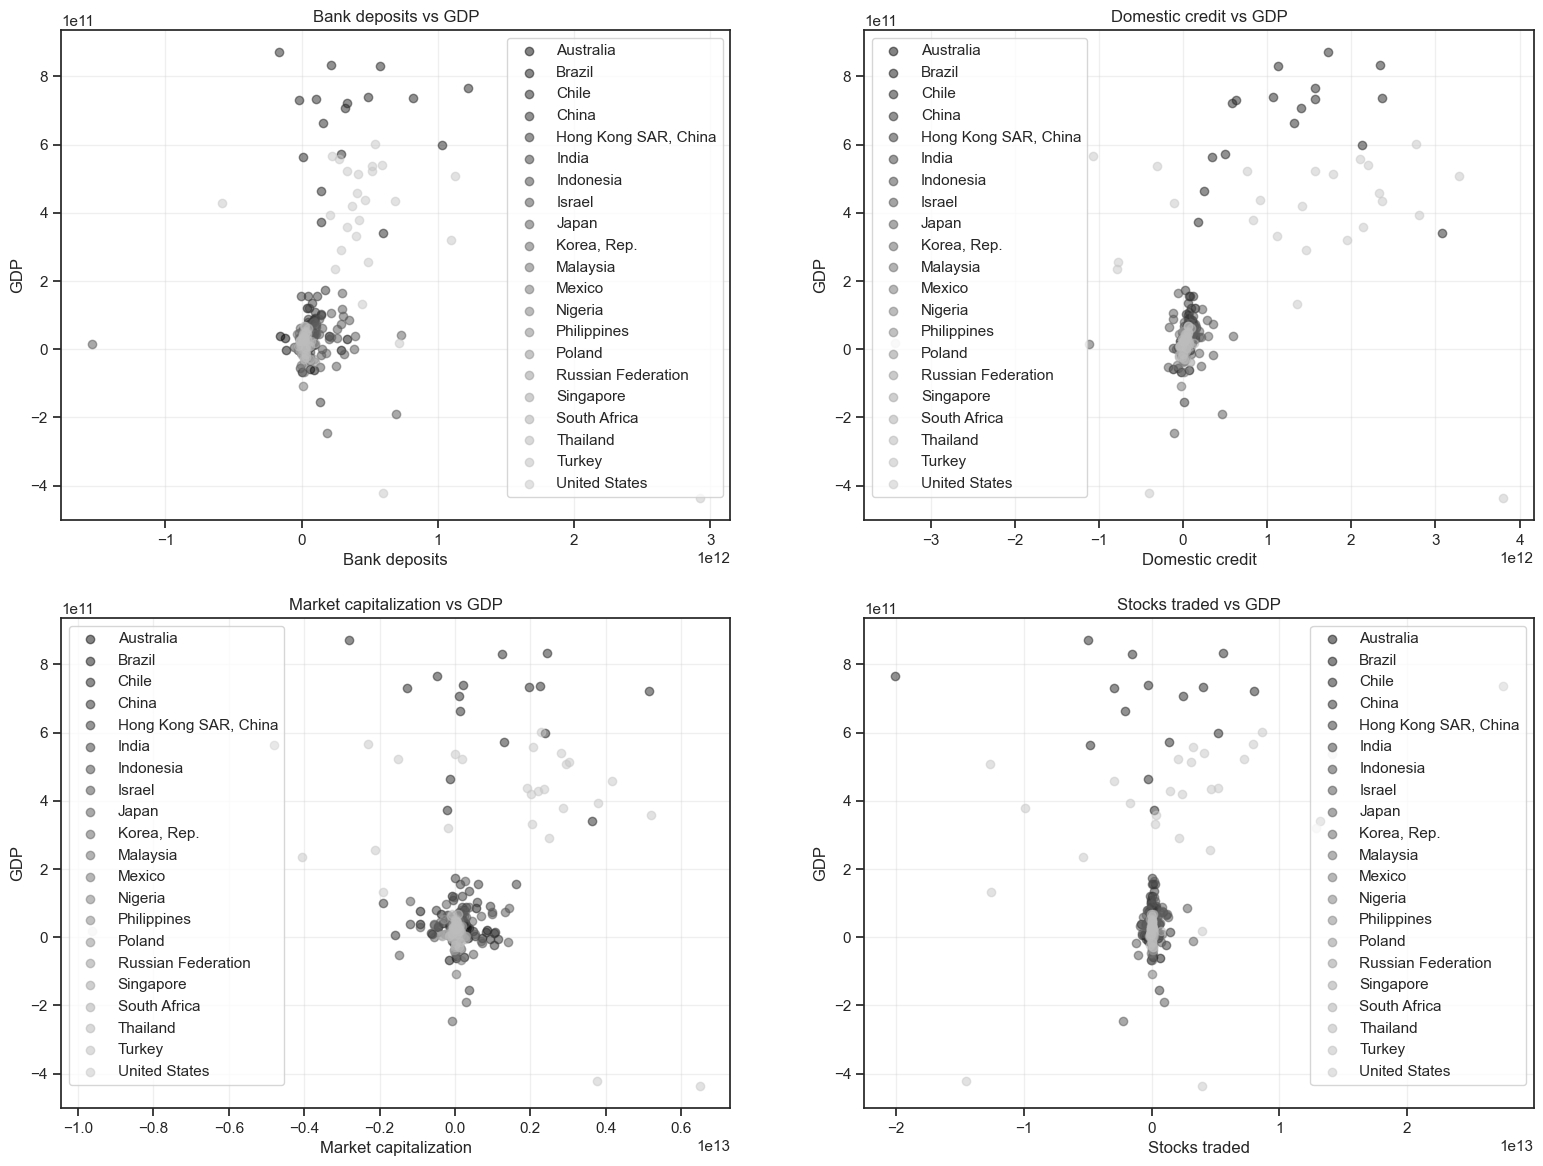

In [26]:
sns.set_theme(style="ticks", font_scale=1)
# Create visualization to understand the data
fig, axes = plt.subplots(2, 2, figsize=(19, 14))

# 1. Time trends by company
for country in data_test_df.index.get_level_values(0).unique():
    data_test_df_temp = data_test_df.loc[country]
    axes[0, 0].scatter(data_test_df_temp['Bank deposits']
                       , data_test_df_temp['GDP']
                       , alpha=0.5
                       # , s = 10
                       , label=country
                       # , marker ='.'
                       , color = sns.color_palette('gray', len(data_test_df.index.get_level_values(0).unique())+5)[list(data_test_df.index.get_level_values(0).unique()).index(country)])
    axes[0, 0].set_xlabel('Bank deposits')
    axes[0, 0].set_ylabel('GDP')
    axes[0, 0].set_title('Bank deposits vs GDP')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()


# 2. R&D spending trends
for country in data_test_df.index.get_level_values(0).unique():
    data_test_df_temp = data_test_df.loc[country]
    axes[0, 1].scatter(data_test_df_temp['Domestic credit'], data_test_df_temp['GDP'], alpha=0.5, label=country, color = sns.color_palette('gray', len(data_test_df.index.get_level_values(0).unique())+5)[list(data_test_df.index.get_level_values(0).unique()).index(country)])
    axes[0, 1].set_xlabel('Domestic credit')
    axes[0, 1].set_ylabel('GDP')
    axes[0, 1].set_title('Domestic credit vs GDP')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()


# 3. Scatter plot: R&D vs Profit Margin
for country in data_test_df.index.get_level_values(0).unique():
    data_test_df_temp = data_test_df.loc[country]
    axes[1, 0].scatter(data_test_df_temp['Market capitalization'], data_test_df_temp['GDP'], alpha=0.5, label=country, color = sns.color_palette('gray', len(data_test_df.index.get_level_values(0).unique())+5)[list(data_test_df.index.get_level_values(0).unique()).index(country)])
    axes[1, 0].set_xlabel('Market capitalization')
    axes[1, 0].set_ylabel('GDP')
    axes[1, 0].set_title('Market capitalization vs GDP')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()

# 4. Boxplot by company
for country in data_test_df.index.get_level_values(0).unique():
    data_test_df_temp = data_test_df.loc[country]
    axes[1, 1].scatter(data_test_df_temp['Stocks traded'], data_test_df_temp['GDP'], alpha=0.5, label=country, color = sns.color_palette('gray', len(data_test_df.index.get_level_values(0).unique())+5)[list(data_test_df.index.get_level_values(0).unique()).index(country)])
    axes[1, 1].set_xlabel('Stocks traded')
    axes[1, 1].set_ylabel('GDP')
    axes[1, 1].set_title('Stocks traded vs GDP')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()

plt.show()

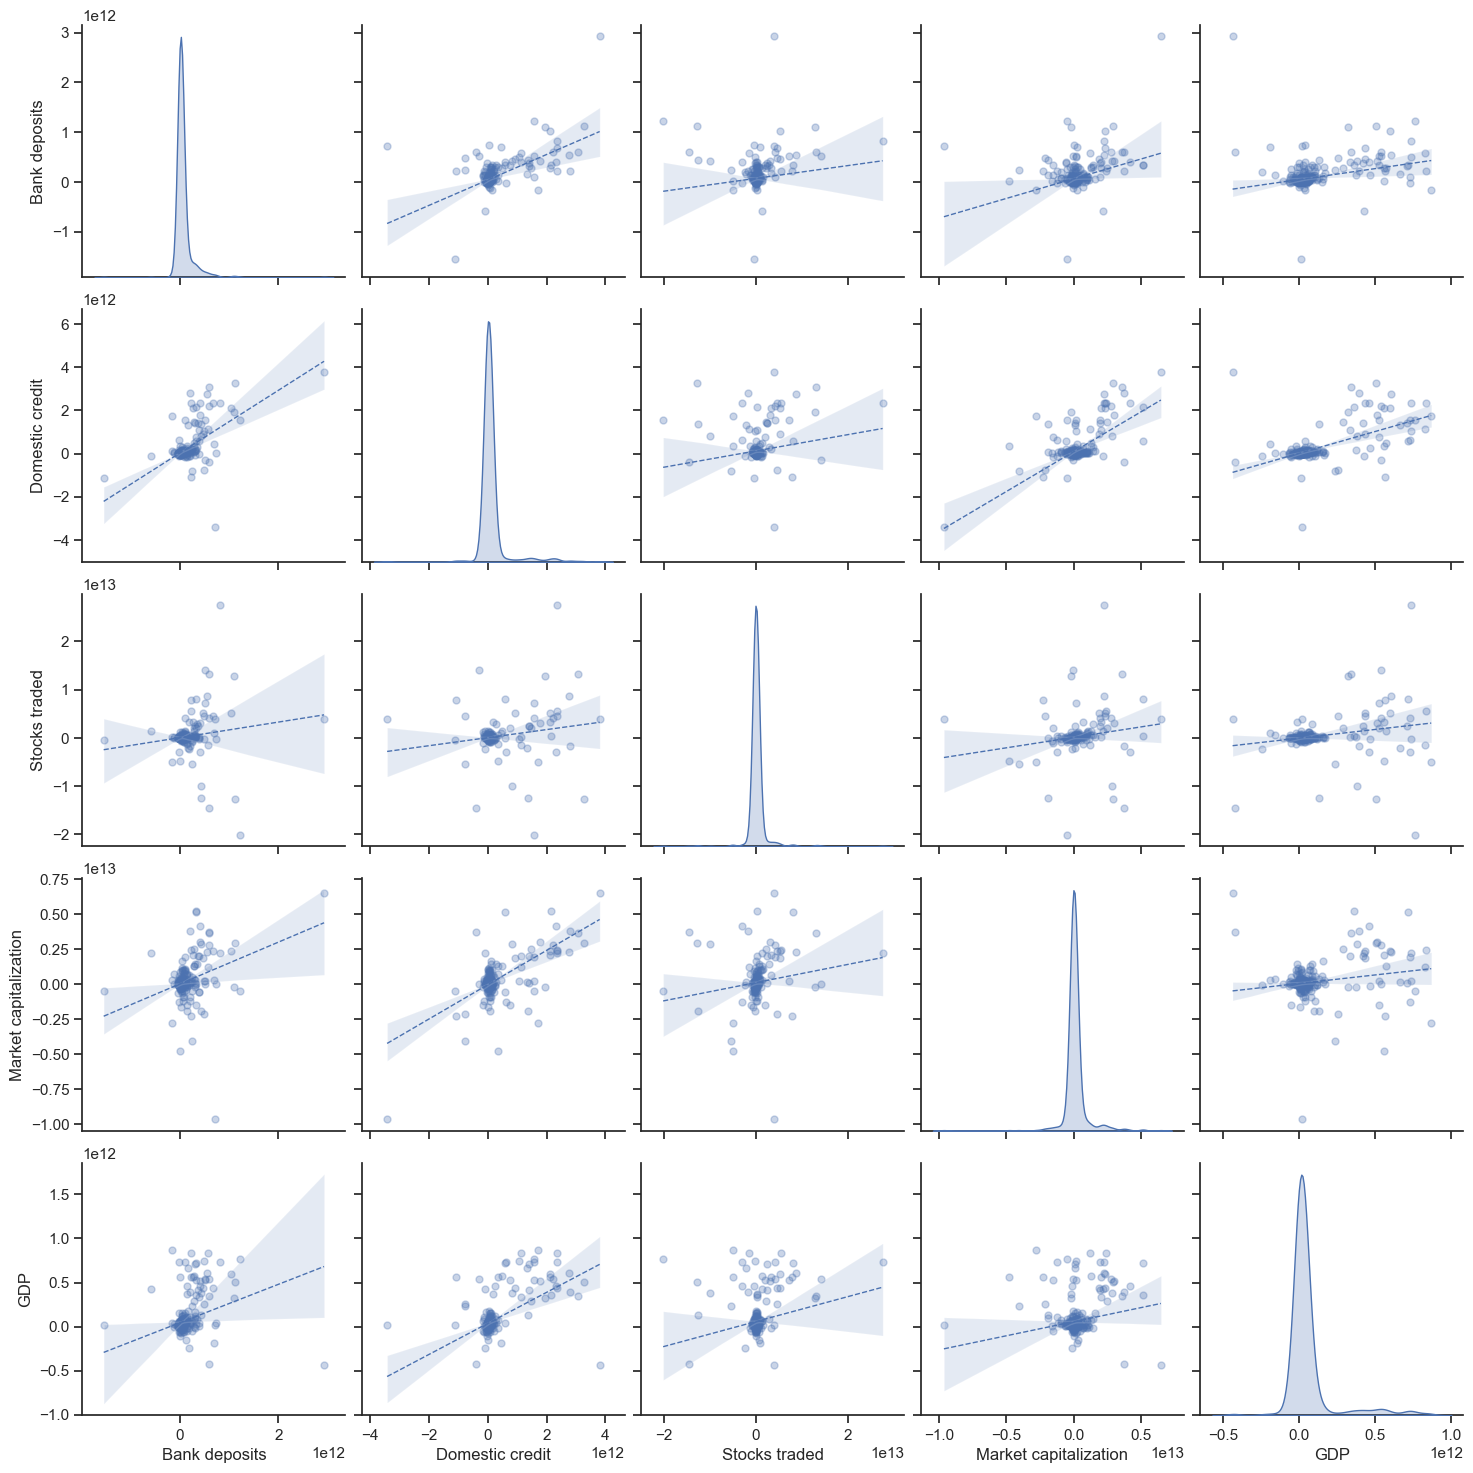

In [27]:
sns.pairplot(
    data_test_df[['Bank deposits'
                  , 'Domestic credit'
                  , 'Stocks traded'
                  , 'Market capitalization'
                  , 'GDP'
                  # , 'Country Name'
                 ]]
    
    , kind='reg'
    , diag_kind = 'kde'
    , height=3
    , plot_kws={'line_kws': {'linestyle': '--'
                             , 'linewidth': 1
                            }
                , 'scatter_kws': {'s': 25
                                  , 'alpha': 0.3}
               }
    , dropna=True
)


In [28]:
# Prepare variables
# Note: linearmodels requires explicit addition of constant for some models
X = data_test_df[['Bank deposits'
                  , 'Domestic credit'
                  , 'Stocks traded'
                  , 'Market capitalization'
                 ]]
y = data_test_df['GDP']

# Add constant for models that need it
X_with_const = sm.add_constant(X)

print("="*60)
print("PANEL DATA REGRESSION RESULTS")
print("="*60)

# 1. POOLED OLS (ignores panel structure)
print("\n1. POOLED OLS MODEL")
print("-"*40)
pooled_model = PooledOLS(y, X_with_const)
pooled_results = pooled_model.fit(cov_type='robust')
print(pooled_results)

# 2. FIXED EFFECTS MODEL (entity effects)
print("\n2. FIXED EFFECTS MODEL")
print("-"*40)
# entity_effects=True includes fixed effects for each company
fe_model = PanelOLS(y, X, entity_effects=True)
fe_results = fe_model.fit(cov_type='clustered', cluster_entity=True)
print(fe_results)

# 3. RANDOM EFFECTS MODEL
print("\n3. RANDOM EFFECTS MODEL")
print("-"*40)
re_model = RandomEffects(y, X_with_const)
re_results = re_model.fit(cov_type='robust')
print(re_results)

# 4. TWO-WAY FIXED EFFECTS (entity + time effects)
print("\n4. TWO-WAY FIXED EFFECTS MODEL")
print("-"*40)
twfe_model = PanelOLS(y, X, entity_effects=True, time_effects=True)
twfe_results = twfe_model.fit(cov_type='clustered', cluster_entity=True)
print(twfe_results)

PANEL DATA REGRESSION RESULTS

1. POOLED OLS MODEL
----------------------------------------
                          PooledOLS Estimation Summary                          
Dep. Variable:                    GDP   R-squared:                        0.4638
Estimator:                  PooledOLS   R-squared (Between):              0.7221
No. Observations:                 500   R-squared (Within):              -0.4756
Date:                Mon, Mar 02 2026   R-squared (Overall):              0.4638
Time:                        17:34:05   Log-likelihood                -1.343e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      107.04
Entities:                          21   P-value                           0.0000
Avg Obs:                       23.810   Distribution:                   F(4,495)
Min Obs:                       11.000                                           
Max Obs:         

In [ ]:
fe_model = PanelOLS(y, X)
fe_results = fe_model.fit()
print(fe_results)

In [ ]:
fe_model = PanelOLS(y, X, time_effects=True)
fe_results = fe_model.fit(cov_type='clustered', cluster_entity=True)
print(fe_results)

In [ ]:
fe_model = PanelOLS(y, X, entity_effects=True)
fe_results = fe_model.fit(cov_type='clustered', cluster_entity=True)
print(fe_results)

In [ ]:
X = data_test_df[['Bank deposits'
                  , 'Domestic credit'
                  , 'Stocks traded'
                  , 'Market capitalization'
                 ]]
y = data_test_df['GDP']

In [ ]:
data_test_df = data_test_df.reset_index()

In [ ]:
# data_test_df

In [ ]:
sns.set_theme(style="ticks", font_scale=1.5)

sns.pairplot(
    data_test_df[['Bank deposits'
                  , 'Domestic credit'
                  , 'Stocks traded'
                  , 'Market capitalization'
                  , 'GDP'
                  # , 'Country Name'
                 ]]
    
    # , x_vars=['Value-traded'
    #           , 'Turnover'
    #           , 'MarCap to GDP'
              
    #           , 'Deposits to GDP'
    #           , 'Broad money'
    #           , 'Credit to private'
    #          ]
    # , y_vars=["Growth rate"]
    # , hue = 'Country Name'
    
    , kind='reg'
    , height=4
    , plot_kws={'line_kws': {'linestyle': '--'
                             , 'linewidth': 1
                            }
                , 'scatter_kws': {'s': 25
                                  , 'alpha': 0.3}
               }
    , dropna=True
)


In [ ]:
df = data_test_df[['GDP', 'Country Name']]

In [ ]:
custom_order = list(df.groupby('Country Name').mean().sort_values('GDP').index)

In [ ]:
df['Country Name'] = pd.Categorical(df['Country Name'], categories=custom_order, ordered=True)

# 4. Sort the DataFrame by the 'Size' column
# This will now use the custom categorical order
df = df.sort_values(by='Country Name')

In [ ]:
df = df[~df['Country Name'].isin(['United States', 'China'])]

In [ ]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['GDP'].quantile(0.25)
Q3 = df['GDP'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.75 * IQR
upper_bound = Q3 + 1.75 * IQR

# Filter the DataFrame to keep only non-outlier rows
df = df[(df['GDP'] >= lower_bound) & (df['GDP'] <= upper_bound)]

In [ ]:
# import numpy as np
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# # Create the data
# rs = np.random.RandomState(1979)
# x = rs.randn(1400)
# g = np.tile(list("ABCDEFGHIJKLMN"), 100)
# df = pd.DataFrame(dict(x=x, g=g))
# m = df.g.map(ord)
# df["GDP"] += m

# Initialize the FacetGrid object
pal = sns.cubehelix_palette(21, rot=-.25, light=.7)
g = sns.FacetGrid(df, row="Country Name", hue="Country Name", aspect=15, height=0.75, palette=pal)

# Draw the densities in a few steps
g.map(sns.kdeplot, "GDP",
      bw_adjust=.5, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "GDP", clip_on=False, color="w", lw=2, bw_adjust=.5)

# passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)


# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)


g.map(label, "GDP")

# Set the subplots to overlap
g.figure.subplots_adjust(hspace=-.25)

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)